# PINN Inverse Heston


In [9]:
# Standard library imports
import os
import time
from pathlib import Path

# Data manipulation and mathematics
import numpy as np
import pandas as pd
from scipy.stats import norm

# Visualization
import matplotlib.pyplot as plt
from matplotlib import cm

# Deep learning framework (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim


### Colab Setup


In [10]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_url = "https://github.com/egil10/fys5429.git"
    repo_dir = "/content/fys5429"

    if not os.path.exists(repo_dir):
        !git clone {repo_url} {repo_dir}
    else:
        !git -C {repo_dir} pull

    os.chdir(os.path.join(repo_dir, "code", "notebooks"))

print(f"Working directory: {os.getcwd()}")


Already up to date.
Working directory: /content/fys5429/code/notebooks


### Paths


In [11]:
data_path = Path("..") / "data" / "generated" / "inv_collocation.parquet"

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    out_dir = Path("/content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/final")
else:
    out_dir = Path("..") / "plots" / "final"

out_dir.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {out_dir}")

out_path_pinn = out_dir / "pinn_inv.pdf"
out_path_loss_total = out_dir / "pinn_inv_loss_total.pdf"
out_path_loss_pde = out_dir / "pinn_inv_loss_pde.pdf"
out_path_loss_ic = out_dir / "pinn_inv_loss_ic.pdf"
out_path_loss_bc = out_dir / "pinn_inv_loss_bc.pdf"
out_path_loss_data = out_dir / "pinn_inv_loss_data.pdf"
out_path_params = out_dir / "pinn_inv_params.pdf"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Plots will be saved to: /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/final


### Global parameters


In [12]:
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
torch.backends.cudnn.benchmark = True

# Domain
S_max = 300.0
T_max = 1.0
K = 100.0
r = 0.05
v_min = 0.01
v_max = 1.0
v0 = 0.04

# True Heston parameters (targets for calibration)
TRUE_KAPPA = 2.0
TRUE_THETA = 0.04
TRUE_XI = 0.3
TRUE_RHO = -0.7

# NN architecture (proven from forward sweeps)
HIDDEN_LAYERS = 3
NEURONS_PER_LAYER = 256
ACTIVATION = 'siren'        # NEW: use 'siren', 'gelu', 'silu', or 'tanh'

# Learning Rates
LEARNING_RATE = 2e-3  # NN learning
LR_HESTON = 1e-3      # Heston param learning

# Two-Stage Optimization Epochs
EPOCHS_ADAM = 25000
EPOCHS_LBFGS = 5000
PRINT_ROWS = 20

# Physics lambdas (Found via hyper_inv sweep)
LAMBDA_PDE = 20.0     
LAMBDA_IC  = 10.0
LAMBDA_BC  = 5.0
LAMBDA_FELLER = 0.1   
LAMBDA_DATA = 1000.0  # Safe high value

# Intentionally wrong initial guesses
KAPPA_INIT = 1.0
THETA_INIT = 0.1
XI_INIT = 0.5
RHO_INIT = 0.0


Using device: cuda


In [13]:
import sys
sys.path.insert(0, "../scripts")
from invpinn import INVPINN

### Reading data


In [14]:
df_all = pd.read_parquet(data_path)

def extract_tensors(df_subset):
    S = torch.tensor(df_subset['S'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    v = torch.tensor(df_subset['v'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    tau = torch.tensor(df_subset['tau'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    return S, v, tau

df_interior = df_all[df_all['point_type'] == 'interior']
S_in, v_in, tau_in = extract_tensors(df_interior)

df_ic = df_all[df_all['point_type'] == 'initial_condition']
S_ic, v_ic, tau_ic = extract_tensors(df_ic)

df_bc = df_all[df_all['point_type'] == 'boundary_S_lower']
S_bc, v_bc, tau_bc = extract_tensors(df_bc)

df_data = df_all[df_all['point_type'] == 'market_data']
S_data, v_data, tau_data = extract_tensors(df_data)
V_data = torch.tensor(df_data['V_data'].values, dtype=torch.float32).view(-1, 1).to(device)

print(f"Read data from {data_path}")
print(f"Interior: {len(S_in)}, IC: {len(S_ic)}, BC: {len(S_bc)}, Data: {len(S_data)}")

Read data from ../data/generated/inv_collocation.parquet
Interior: 10000, IC: 2000, BC: 250, Data: 200


In [15]:
model = INVPINN(hidden_layers=HIDDEN_LAYERS, neurons_per_layer=NEURONS_PER_LAYER,
                activation=ACTIVATION,
                kappa_init=KAPPA_INIT, theta_init=THETA_INIT,
                xi_init=XI_INIT, rho_init=RHO_INIT).to(device)

optimizer_adam = optim.Adam(model.param_groups(lr_nn=LEARNING_RATE, lr_heston=LR_HESTON))
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer_adam, T_max=EPOCHS_ADAM, eta_min=1e-6)

optimizer_lbfgs = optim.LBFGS(model.parameters(), max_iter=1, history_size=50, 
                              tolerance_grad=1e-5, tolerance_change=1e-9, 
                              line_search_fn="strong_wolfe")


### Training Loop


In [16]:
history = {
    'epoch': [], 'total': [], 'pde': [], 'ic': [], 'bc': [], 'data': [], 'feller': [],
    'kappa': [], 'theta': [], 'xi': [], 'rho': []
}

print(f"{'Epoch':>6} | {'Total':>12} | {'PDE':>10} | {'IC':>10} | {'BC':>10} | {'Data':>10} | {'Feller':>10} | {'κ':>6} {'θ':>7} {'ξ':>6} {'ρ':>7}")
print("-" * 120)

grad_ones = torch.ones_like(S_in)
start_time = time.time()
total_epochs = EPOCHS_ADAM + EPOCHS_LBFGS
print_interval = max(1, total_epochs // PRINT_ROWS)

# ==========================================
# 1. THE LOSS CLOSURE FUNCTION
# ==========================================
def compute_loss():
    kappa, theta, xi, rho = model.kappa, model.theta, model.xi, model.rho

    V_pred = model(S_in, v_in, tau_in)
    V_S   = torch.autograd.grad(V_pred, S_in,   grad_outputs=grad_ones, create_graph=True)[0]
    V_v   = torch.autograd.grad(V_pred, v_in,   grad_outputs=grad_ones, create_graph=True)[0]
    V_tau = torch.autograd.grad(V_pred, tau_in, grad_outputs=grad_ones, create_graph=True)[0]
    V_SS  = torch.autograd.grad(V_S, S_in,      grad_outputs=grad_ones, create_graph=True)[0]
    V_vv  = torch.autograd.grad(V_v, v_in,      grad_outputs=grad_ones, create_graph=True)[0]
    V_Sv  = torch.autograd.grad(V_S, v_in,      grad_outputs=grad_ones, create_graph=True)[0]

    pde_residual = V_tau - (
        0.5 * v_in * S_in**2 * V_SS + rho * xi * v_in * S_in * V_Sv + 0.5 * xi**2 * v_in * V_vv
        + r * S_in * V_S + kappa * (theta - v_in) * V_v - r * V_pred
    )
    loss_pde = torch.mean(pde_residual**2)
    loss_ic = torch.mean((model(S_ic, v_ic, tau_ic) - torch.relu(S_ic - K))**2)
    loss_bc = torch.mean((model(S_bc, v_bc, tau_bc) - 0.0)**2)
    loss_data = torch.mean((model(S_data, v_data, tau_data) - V_data)**2)
    loss_feller = torch.relu(xi**2 - 2.0 * kappa * theta)**2

    loss = (LAMBDA_PDE * loss_pde + LAMBDA_IC * loss_ic + LAMBDA_BC * loss_bc 
            + LAMBDA_DATA * loss_data + LAMBDA_FELLER * loss_feller)
            
    return loss, loss_pde, loss_ic, loss_bc, loss_data, loss_feller, kappa, theta, xi, rho

def log_history(epoch_num):
    # REMOVED the 'with torch.no_grad():' wrapper!
    loss, lp, lic, lbc, ldata, lf, k, t, x, r_corr = compute_loss()
    history['epoch'].append(epoch_num)
    history['pde'].append(lp.item()); history['ic'].append(lic.item())
    history['bc'].append(lbc.item()); history['data'].append(ldata.item())
    history['feller'].append(lf.item()); history['total'].append(loss.item())
    history['kappa'].append(k.item()); history['theta'].append(t.item())
    history['xi'].append(x.item()); history['rho'].append(r_corr.item())
    print(f"{epoch_num:6d} | {loss.item():12.4f} | {lp.item():10.6f} | {lic.item():10.4f} | {lbc.item():10.6f} | {ldata.item():10.4f} | {lf.item():10.6f} | "
          f"{k.item():6.3f} {t.item():7.4f} {x.item():6.3f} {r_corr.item():7.3f}")

# ==========================================
# 2. PHASE 1: ADAM
# ==========================================
for epoch in range(EPOCHS_ADAM):
    optimizer_adam.zero_grad()
    loss, *_ = compute_loss()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer_adam.step()
    scheduler.step()

    if epoch % print_interval == 0: log_history(epoch)

# ==========================================
# 3. PHASE 2: L-BFGS
# ==========================================
for epoch in range(EPOCHS_ADAM, total_epochs):
    def closure():
        optimizer_lbfgs.zero_grad()
        loss, *_ = compute_loss()
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)

    if epoch % print_interval == 0 or epoch == total_epochs - 1: log_history(epoch)

end_time = time.time()
total_seconds = end_time - start_time
print("-" * 120)
print(f"Calibration Complete! {total_epochs} epochs in {int(total_seconds // 60)}m {int(total_seconds % 60)}s")


 Epoch |        Total |        PDE |         IC |         BC |       Data |     Feller |      κ       θ      ξ       ρ
------------------------------------------------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     0 |  292670.5000 |   8.688971 |  4096.9473 |  78.417503 |  5024.4409 |   0.002455 |  0.999  0.1001  0.500  -0.001
  1500 |     398.5698 |  22.288439 |     2.5890 |   0.076936 |     2.9882 |   0.000000 |  1.186  0.0675  0.225   0.102
  3000 |     885.1248 |  59.237831 |     4.0916 |   0.121888 |     5.0244 |   0.000000 |  1.109  0.0666  0.140   0.112
  4500 |     536.0257 |  31.393049 |    10.4820 |   0.345131 |     2.3110 |   0.000000 |  1.045  0.0646  0.096   0.129
  6000 |     396.4257 |  27.395081 |     4.0450 |   0.331290 |     1.6074 |   0.000000 |  1.013  0.0607  0.073   0.142
  7500 |     123.7019 |   2.564680 |     2.2770 |   0.009513 |     1.5048 |   0.000000 |  0.988  0.0569  0.057   0.155
  9000 |     105.9926 |   7.699058 |     0.9204 |   0.039805 |     0.3920 |   0.000000 |  0.989  0.0515  0.047   0.161
 10500 |     102.5595 |   5.443422 |     1.3702 |   0.019775 |     0.6865 |   0.000000 |  0.987  0.0467  0.040   0.166
 12000 |      47.0109 |   2.914899 |     0.6214 

### Parameter Convergence Plot


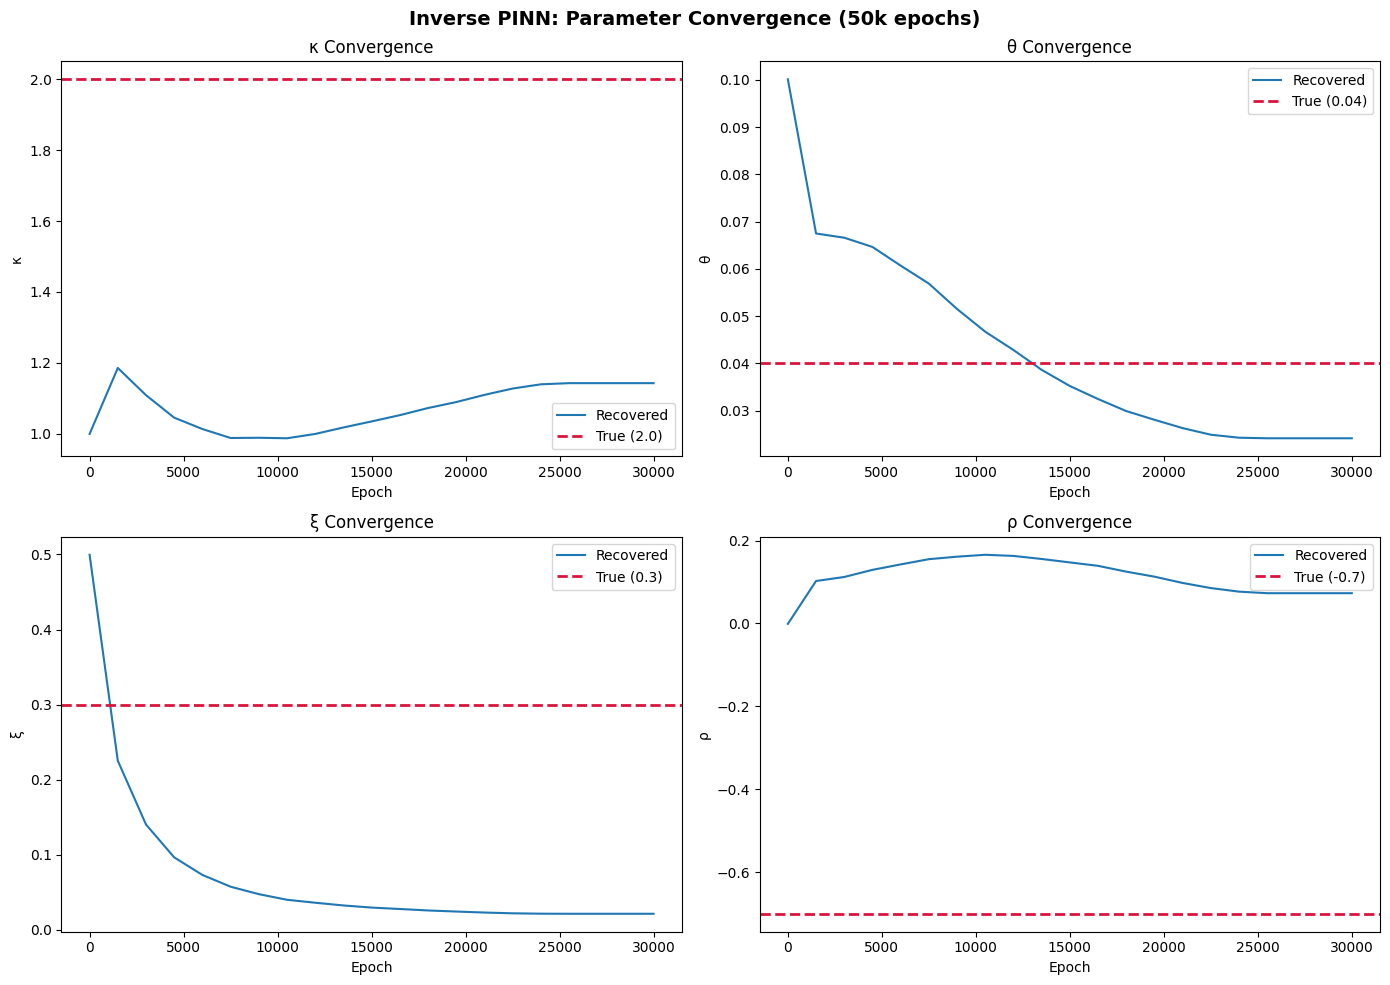

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

params = [('kappa', 'κ', TRUE_KAPPA), ('theta', 'θ', TRUE_THETA),
          ('xi', 'ξ', TRUE_XI), ('rho', 'ρ', TRUE_RHO)]

for ax, (key, label, true_val) in zip(axes.flat, params):
    ax.plot(history['epoch'], history[key], label='Recovered', linewidth=1.5)
    ax.axhline(y=true_val, color='crimson', linestyle='--', linewidth=2, label=f'True ({true_val})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(label)
    ax.set_title(f'{label} Convergence')
    ax.legend()

plt.suptitle('Inverse PINN: Parameter Convergence (50k epochs)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(out_path_params, bbox_inches="tight")
plt.show()

### Loss Curves


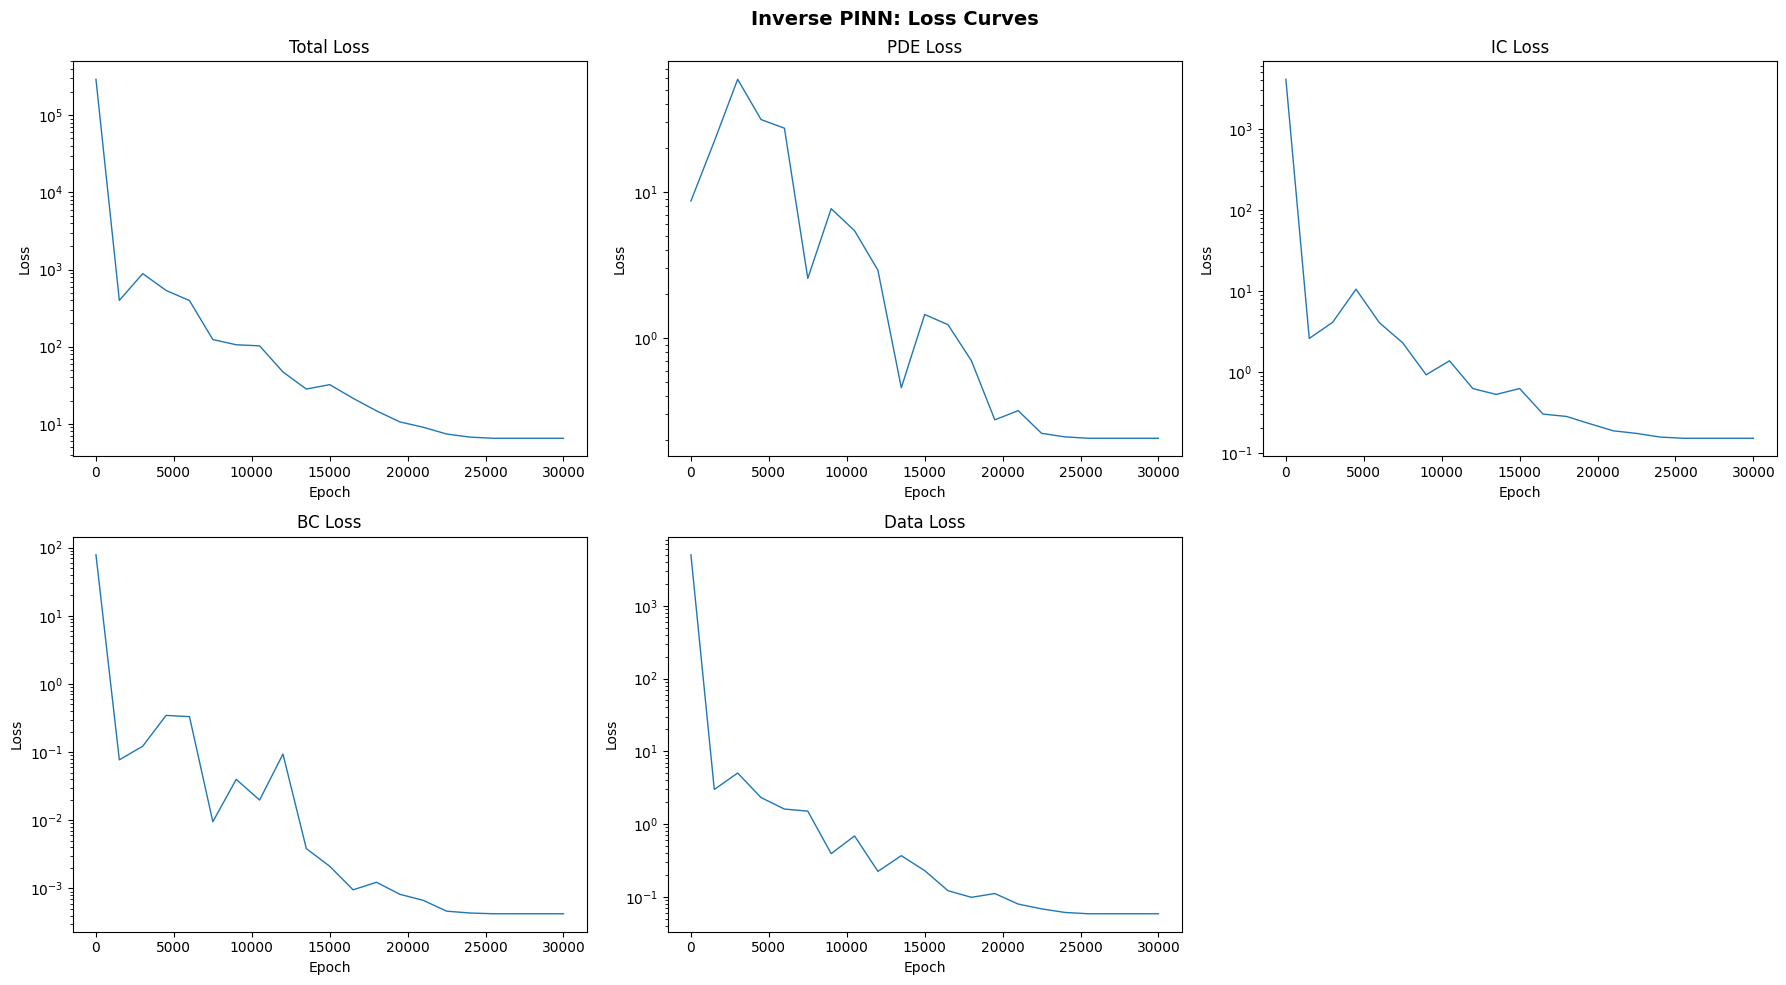

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

loss_keys = [('total', 'Total Loss'), ('pde', 'PDE Loss'), ('ic', 'IC Loss'),
             ('bc', 'BC Loss'), ('data', 'Data Loss')]
out_paths = [out_path_loss_total, out_path_loss_pde, out_path_loss_ic,
             out_path_loss_bc, out_path_loss_data]

for i, (ax, (key, title)) in enumerate(zip(axes.flat, loss_keys)):
    ax.semilogy(history['epoch'], history[key], linewidth=1)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(title)

# Hide the unused 6th subplot
axes.flat[5].set_visible(False)

plt.suptitle('Inverse PINN: Loss Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(out_dir / "pinn_inv_losses.pdf", bbox_inches="tight")
plt.show()


In [19]:
if IN_COLAB:
    from google.colab import drive
    drive.flush_and_unmount()
    print("Google Drive flushed and unmounted safely.")


Google Drive flushed and unmounted safely.
